## BLINKIT ANALYSIS 


#### Import libarires

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Import raw data

In [32]:
df = pd.read_csv("C:/Users/Aditya/OneDrive/Desktop/DA Project Excel/python project/blinkit_data.csv")

### **Sample Data**

In [33]:
df.head(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2000,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


### **Size of Data**

In [34]:
print("Size of Data:", df.shape)

Size of Data: (8523, 12)


### **Field info**

In [35]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

### **Data Type**

In [36]:
df.dtypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

### **Data Cleaning**

In [37]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [45]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'LF':'Low Fat',
                                                       'low fat':'Low Fat',
                                                       'reg': 'Regular'})

In [46]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat']


### **BUSINESS REQUIREMENTS**

### ** KPI's  REQUIREMENTS**

In [52]:
# Total Sales
total_sales = df['Sales'].sum()

# Average Sales
avg_sales = df['Sales'].mean()

# No of items Sold
no_of_items_sold = df['Sales'].count()

# Average Ratings
avg_ratings = df['Rating'].mean()

# Display
print(f"Total Sales: ${total_sales:,.0f}")
print(f"Average Sales: ${avg_sales:,.0f}")
print(f"No of items Sold: {no_of_items_sold:,.0f}")
print(f"Average Ratings: {avg_ratings:.1f}")

Total Sales: $1,201,681
Average Sales: $141
No of items Sold: 8,523
Average Ratings: 4.0


### ** CHARTS**

#### **Total Sales by Fat Content**


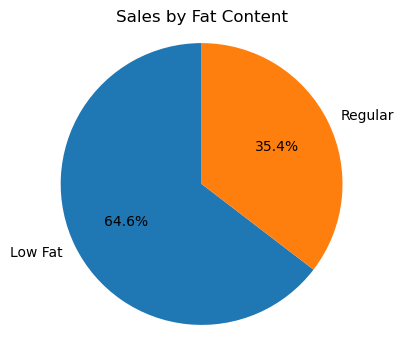

In [75]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()

plt.figure(figsize=(4, 4)) 
plt.pie(sales_by_fat, labels = sales_by_fat.index,
                       autopct = '%.1f%%',
                       startangle=90)
 
plt.title('Sales by Fat Content')
plt.axis('equal')
plt.show()


#### Total Sales by Item Type ####

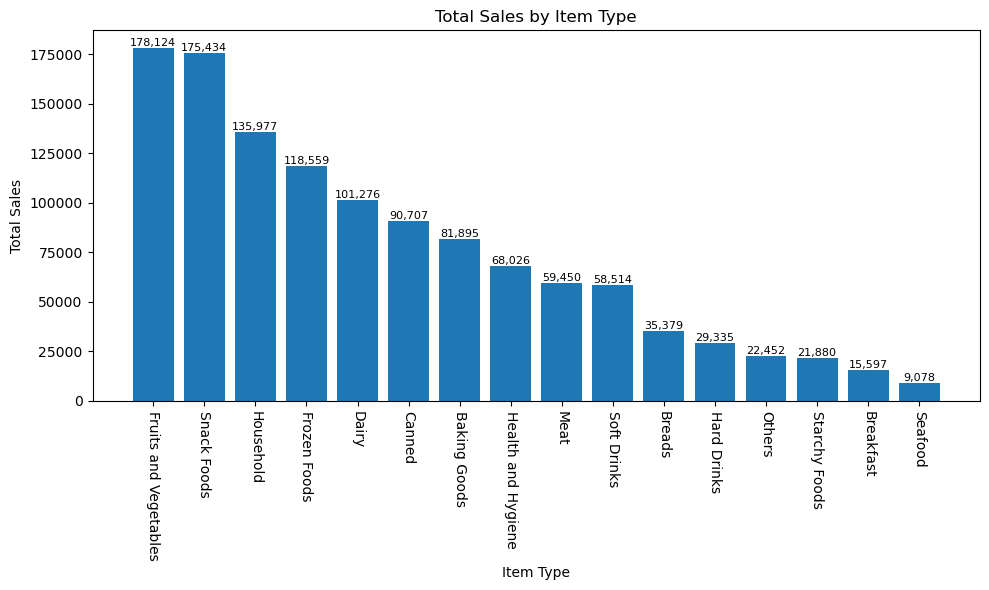

In [66]:
import matplotlib.pyplot as plt

# Grouping
sales_by_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(sales_by_type.index, sales_by_type.values)

# Labels
plt.xticks(rotation=-90)
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.title('Total Sales by Item Type')

# Add values on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()

#### Fat Content by Outlet for Total Sales

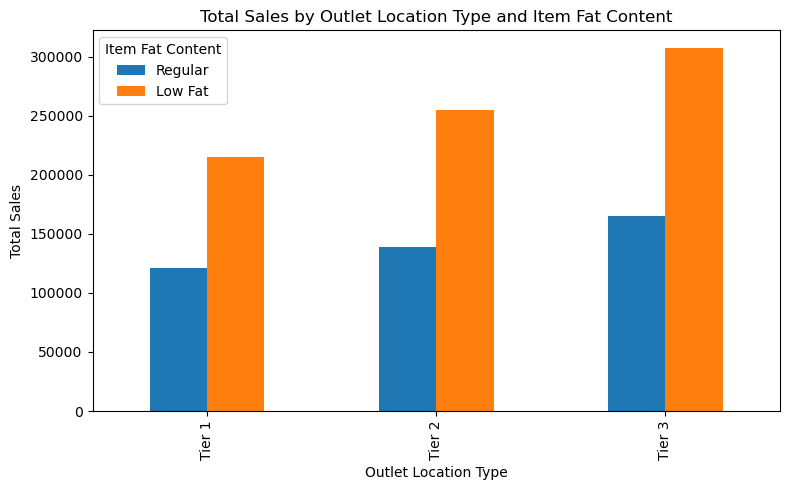

In [65]:
grouped = df.groupby(['Outlet Location Type', 'Item Fat Content'])['Sales'].sum().unstack()
grouped= grouped[['Regular','Low Fat']]
# Plotting the data
ax = grouped.plot(kind='bar', figsize=(8, 5), title='Outlet Tier by Item Fat Content')

# Setting titles and labels
plt.title('Total Sales by Outlet Location Type and Item Fat Content')
plt.xlabel("Outlet Location Type")
plt.ylabel('Total Sales')
plt.legend(title='Item Fat Content')

# Formatting and showing
plt.tight_layout()
plt.show()

#### Total Sales by Outlet Establishment

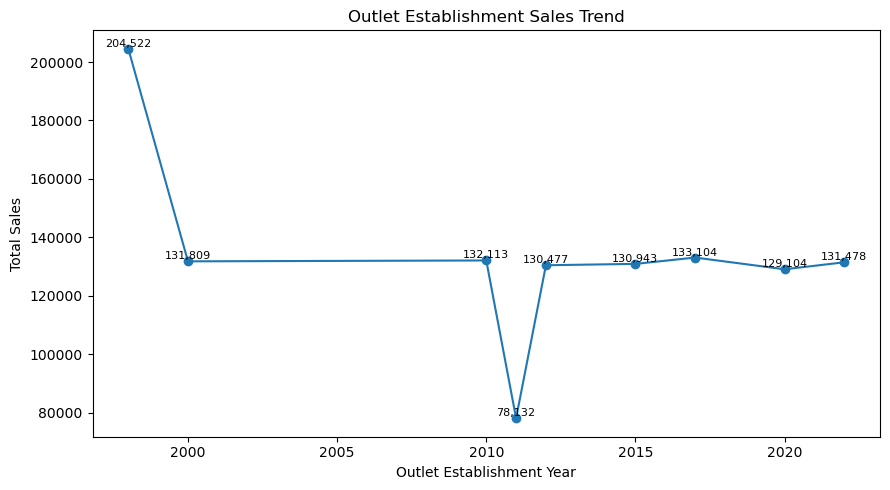

In [67]:
# Group by 'Outlet Establishment Year' and sum the 'Sales'
sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()

# Initialize the figure size
plt.figure(figsize=(9,5))

# Plot the sales trend with markers
plt.plot(sales_by_year.index, sales_by_year.values, marker='o', linestyle="-")

# Add chart labels and title
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment Sales Trend')

# Annotate each data point with its value
for x, y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

#### Sales by Outlet Size

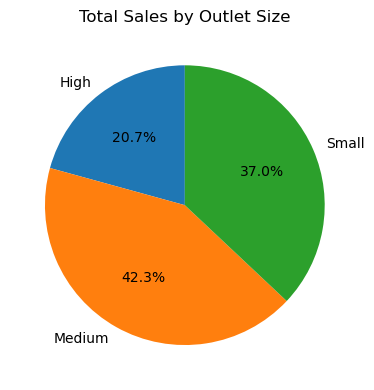

In [69]:
# Grouping and summing the sales data
sales_by_size = df.groupby('Outlet Size')['Sales'].sum()

# Creating the pie chart figure
plt.figure(figsize=(4, 4)) # Increased size for better readability

# Plotting the pie chart with labels and percentages
plt.pie(sales_by_size, 
        labels=sales_by_size.index, 
        autopct='%1.1f%%',  # Fixed: comma, changed 1.14%% to 1.1f%% for readability
        startangle=90)      # Standardized start angle

# Adding title
plt.title('Total Sales by Outlet Size')

#  Displaying the chart
plt.tight_layout()
plt.show()

#### Sales by Outlet Location

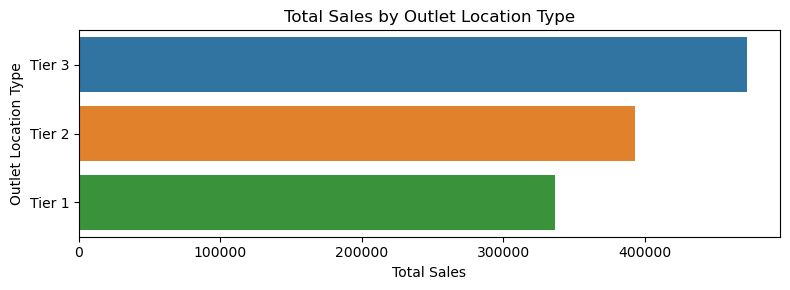

In [73]:
# Group and sum the sales by location type
sales_by_location = df.groupby('Outlet Location Type')['Sales'].sum().reset_index()

#  Sort the values in descending order
sales_by_location = sales_by_location.sort_values('Sales', ascending=False)

#  Create the visualization
plt.figure(figsize=(8, 3))
sns.barplot(x='Sales', y='Outlet Location Type', data=sales_by_location)

#  Add labels and formatting
plt.title('Total Sales by Outlet Location Type')
plt.xlabel('Total Sales')
plt.ylabel('Outlet Location Type')
plt.tight_layout()

#  Display the plot
plt.show()